In [2]:
import math
import matplotlib.pyplot as plt
pi = math.pi

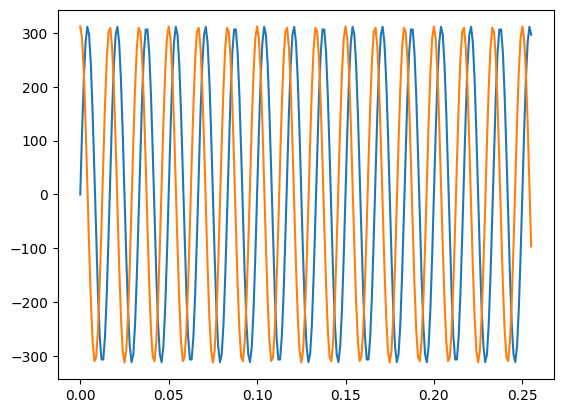

In [6]:
# 256 muestras a 1000 samples/second (~ 1KB)
# Imitando las limitaciones de un arduino
v_sample = [] # Función de voltaje
i_sample = [] # Función de intensidad
time = []
for i in range(256):
  v_sample.append(312 * math.sin(120*pi*i*0.001))         # Normal
  i_sample.append(312 * math.sin(pi/2 + 120*pi*i*0.001))  # Adelantado 90°
  time.append(i*0.001)

plt.plot(time, v_sample)
plt.plot(time, i_sample)
plt.show()

In [39]:
def schmidt_trigger(sample):
  umbral_inferior = -50
  umbral_superior = 50
  output = []
  state = False

  for element in sample:
    if element > umbral_superior and not state:
      output.append(1)
      state = True
    elif element < umbral_inferior and state:
      output.append(-1)
      state = False
    elif state:
      output.append(1)
    elif not state:
      output.append(-1)

  return output

In [40]:
v_st = schmidt_trigger(v_sample)  # Aplicar schmidt trigger a ambas funciones
i_st = schmidt_trigger(i_sample)

In [42]:
v_turning = []  # Puntos de inflexión
i_turning = []
for i in range(255):
  if v_st[i] == -1 and v_st[i+1] == 1:  # Rising edge voltaje
    v_turning.append(i)
  if i_st[i] == -1 and i_st[i+1] == 1:  # Rising edge intensidad
    i_turning.append(i)

a = 0
for i in range(min([len(v_turning), len(i_turning)])):
  a = a + (v_turning[i] - i_turning[i])       # Diferencia tiempo entre rising edges
a = a / min([len(v_turning), len(i_turning)]) # Diferencia promedio
a = a * 360 / 16.667                          # Ángulo (debe salir cercano a 90°)

print("Ángulo de desfase:", a+360)

Ángulo de desfase: 93.60532789344217
